In [1]:
import sys
from pathlib import Path

# Use current working directory instead
project_root = Path().resolve().parent.parent  # Adjust `.parent` as needed
sys.path.append(str(project_root))

from data.download.download import get_dataset_files, download_file_by_id

Get the label and file ids for download

In [2]:
# GX017072.pkl        
# GX017072_part1.MP4 
# GX017072_part2.MP4
import yaml
dataset = 'coralcam'
dataverse = yaml.safe_load(open('../../config/actual/dataverse.yml', 'r'))
config = yaml.safe_load(open(f'../../config/actual/dataset.yml'))
DATAVERSE_URL = dataverse['url']
API_KEY = dataverse['api_key']
HEADERS = {"X-Dataverse-key": API_KEY}
doi = config[dataset]['doi']
files = get_dataset_files(DATAVERSE_URL, doi, HEADERS)

label = [file for file in files if file['filename'] == 'GX017072.pkl'][0]
part1 = [file for file in files if file['filename'] == 'GX017072_part1.MP4'][0]
print(label, part1)

{'file_id': 11452975, 'filename': 'GX017072.pkl'} {'file_id': 11452964, 'filename': 'GX017072_part1.MP4'}


In [3]:
#download if not exists
if not Path(label['filename']).exists():
    print(f"Downloading {label['filename']}...")
    download_file_by_id(DATAVERSE_URL, part1['file_id'], part1['filename'], HEADERS)

if not Path(part1['filename']).exists():
    print(f"Downloading {part1['filename']}...")
    download_file_by_id(DATAVERSE_URL, label['file_id'], label['filename'], HEADERS)

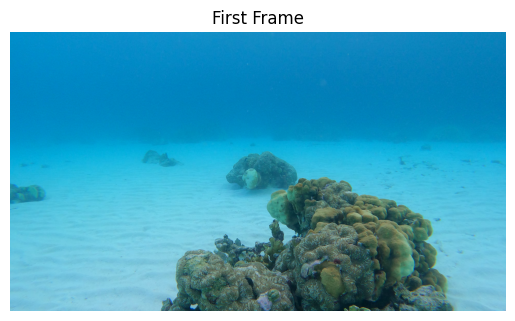

In [4]:
import av
import matplotlib.pyplot as plt

def show_first_frame(video_path):
    container = av.open(video_path)
    for frame in container.decode(video=0):
        img = frame.to_ndarray(format='rgb24')  # matplotlib expects RGB
        plt.imshow(img)
        plt.title("First Frame")
        plt.axis("off")
        plt.show()
        break

show_first_frame(part1['filename'])

In [ ]:
#read the pkl file 
import pickle
with open(label['filename'], 'rb') as f:
    data = pickle.load(f)
print(data)
